# Notebook 1: Data preparation and exploratory analysis

This notebook loads the raw Milan CDR files, ranks the 10,000 grid squares by total Internet traffic, builds 10-minute series for the squares used later, and explores them. The processed series, tables and figures are saved to disk for `02_modeling_and_results.ipynb`, which never reads the raw files.

In [1]:
import gc
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
RESULTS_DIR = Path("../results")
for d in (PROCESSED_DIR, FIGURES_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

COLNAMES = ["square_id", "timestamp_ms", "country_code", "sms_in", "sms_out", "call_in", "call_out", "internet"]
CHUNKSIZE = 2_000_000


def daily_files():
    return sorted(RAW_DIR.glob("sms-call-internet-mi-*.txt"))


def chunk_iter(path, usecols, dtype):
    return pd.read_csv(path, sep="\t", header=None, names=COLNAMES,
                       usecols=usecols, dtype=dtype, chunksize=CHUNKSIZE)


def measure_rss_mb():
    gc.collect()
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)


def reconstruct_series(long_series, full_index):
    # wide table (datetime x square), intervals with no rows are filled with 0
    df = long_series.reset_index()
    df["datetime"] = pd.to_datetime(df["timestamp_ms"], unit="ms")
    wide = df.pivot(index="datetime", columns="square_id", values="internet")
    wide = wide.reindex(full_index).fillna(0.0)
    wide.index.name = "datetime"
    return wide


print(f"Baseline RSS: {measure_rss_mb():.1f} MB")

Baseline RSS: 202.8 MB


## Dataset and Data Preparation

**Source.** The Milan Telecom Italia CDR dataset [1] splits the city into a 100×100 grid of 10,000 squares. For each square and 10-minute interval, the raw files give SMS-in, SMS-out, call-in, call-out and Internet traffic per country code.

**Target.** The forecasting target is Internet traffic: the `internet` column, summed over all `country_code` rows with the same `(square_id, timestamp)`.

**Schema.** Tab-separated, no header: `square_id, timestamp_ms (epoch millis), country_code, sms_in, sms_out, call_in, call_out, internet`. Many fields are empty on any given row, since a row only has values for the activity types that were observed.

**Files.** There is one file per day. The cell below checks that the files for the Dec 16–22 test week are present.

In [2]:
files = daily_files()
dates = [f.stem.replace("sms-call-internet-mi-", "") for f in files]
print(f"{len(files)} daily files found, spanning {dates[0]} to {dates[-1]}")

target_week = pd.date_range("2013-12-16", "2013-12-22", freq="D").strftime("%Y-%m-%d").tolist()
missing = [d for d in target_week if d not in dates]
assert not missing, f"Missing files for target evaluation week: {missing}"
print("All 7 files for the Dec 16-22 target evaluation week are present:", target_week)

62 daily files found, spanning 2013-11-01 to 2014-01-01
All 7 files for the Dec 16-22 target evaluation week are present: ['2013-12-16', '2013-12-17', '2013-12-18', '2013-12-19', '2013-12-20', '2013-12-21', '2013-12-22']


### Two-pass chunked loading

The raw data is about 20 GB in 62 files (one day is ~340 MB, ~5.3M rows). Reading even one file in full with `pd.read_csv` uses a lot of memory, and all 62 together would not fit in the 7.7 GB of RAM of the machine used (see the hardware line in notebook 2). Instead the files are read in two passes, one file at a time in chunks of 2,000,000 rows, with `usecols` so unused columns are never parsed:

1. **Pass 1 (ranking)** reads `square_id` and `internet` from every file and keeps a running total per square. This gives the ranking of all 10,000 squares.
2. **Pass 2 (extraction)** reads `square_id`, `timestamp_ms` and `internet` and keeps only the top-3 squares from Pass 1 plus squares 4159 and 4556, which are then rebuilt as full 10-minute series.

**Trade-offs.** Reading the data twice roughly doubles the I/O time. A single pass is not possible here because the squares to extract are only known once the ranking is finished, and extracting many candidate squares up front would bring back the memory problem. The chunk size is fixed rather than tuned to the available RAM. Memory is also measured after each stage, not at its peak, so the real peak is higher than the table below shows.

In [3]:
# naive baseline: load one day's file in full
mem_before_naive = measure_rss_mb()
t0 = time.time()
_naive_df = pd.read_csv(files[0], sep="\t", header=None, names=COLNAMES)
naive_load_time = time.time() - t0
mem_after_naive = measure_rss_mb()
naive_rows = len(_naive_df)
del _naive_df
gc.collect()

print(f"Naive full load of one file ({files[0].name}): {naive_rows:,} rows in {naive_load_time:.1f}s")
print(f"RSS before: {mem_before_naive:.1f} MB -> after: {mem_after_naive:.1f} MB (delta {mem_after_naive - mem_before_naive:+.1f} MB)")

Naive full load of one file (sms-call-internet-mi-2013-11-01.txt): 4,842,625 rows in 3.2s
RSS before: 204.0 MB -> after: 500.4 MB (delta +296.4 MB)


In [4]:
def frame_mb(df):
    return df.memory_usage(deep=True).sum() / 1024 ** 2


full_df = pd.read_csv(files[0], sep="\t", header=None, names=COLNAMES)
pass1_df = pd.read_csv(files[0], sep="\t", header=None, names=COLNAMES, usecols=["square_id", "internet"],
                       dtype={"square_id": "int32", "internet": "float32"})
pass2_df = pd.read_csv(files[0], sep="\t", header=None, names=COLNAMES, usecols=["square_id", "timestamp_ms", "internet"],
                       dtype={"square_id": "int32", "timestamp_ms": "int64", "internet": "float32"})
sizes = {"all 8 columns, default dtypes": frame_mb(full_df),
         "Pass 1 columns (2), int32/float32": frame_mb(pass1_df),
         "Pass 2 columns (3), int32/int64/float32": frame_mb(pass2_df)}
for name, mb in sizes.items():
    print(f"one day, {name}: {mb:.0f} MB ({100 * (1 - mb / sizes['all 8 columns, default dtypes']):.0f}% smaller)")
del full_df, pass1_df, pass2_df
gc.collect()

one day, all 8 columns, default dtypes: 296 MB (0% smaller)
one day, Pass 1 columns (2), int32/float32: 37 MB (87% smaller)
one day, Pass 2 columns (3), int32/int64/float32: 74 MB (75% smaller)


0

In [5]:
# Pass 1: ranking scan
mem_before_pass1 = measure_rss_mb()
t0 = time.time()

square_totals = pd.Series(dtype="float64")
for f in daily_files():
    for chunk in chunk_iter(f, usecols=["square_id", "internet"],
                             dtype={"square_id": "int32", "internet": "float32"}):
        grp = chunk.groupby("square_id")["internet"].sum()
        square_totals = square_totals.add(grp, fill_value=0.0)

pass1_time = time.time() - t0
mem_after_pass1 = measure_rss_mb()
print(f"Pass 1 (ranking scan) complete in {pass1_time:.1f}s over {len(daily_files())} files")
print(f"RSS before: {mem_before_pass1:.1f} MB -> after: {mem_after_pass1:.1f} MB (delta {mem_after_pass1 - mem_before_pass1:+.1f} MB)")
print(f"Squares seen: {len(square_totals)}")

Pass 1 (ranking scan) complete in 136.4s over 62 files
RSS before: 208.5 MB -> after: 217.6 MB (delta +9.1 MB)
Squares seen: 10000


In [6]:
ranking_df = (
    square_totals.sort_values(ascending=False)
    .rename("total_internet_traffic")
    .reset_index()
)
ranking_df.insert(0, "rank", np.arange(1, len(ranking_df) + 1))
ranking_df["square_id"] = ranking_df["square_id"].astype(int)
ranking_df.to_csv(RESULTS_DIR / "square_ranking.csv", index=False)

top3_ids = ranking_df.iloc[:3]["square_id"].tolist()
print("Top-3 squares by total Internet traffic:", top3_ids)
ranking_df.head(10)

Top-3 squares by total Internet traffic: [5161, 5059, 5259]


,rank,square_id,total_internet_traffic
0,1,5161,1.274006e+07
1,2,5059,1.117085e+07
2,3,5259,1.048578e+07
3,4,5061,9.584334e+06
4,5,5258,8.707440e+06
5,6,5159,8.703873e+06
6,7,6064,8.675343e+06
7,8,4855,8.491044e+06
8,9,4856,8.230212e+06
9,10,5262,8.163357e+06


In [7]:
landmark_ids = [4159, 4556]
selected_ids = sorted(set(top3_ids) | set(landmark_ids))
print("Squares to extract full time series for (top-3 union landmark squares):", selected_ids)

# Pass 2: extraction scan
mem_before_pass2 = measure_rss_mb()
t0 = time.time()

partials = []
for f in daily_files():
    for chunk in chunk_iter(f, usecols=["square_id", "timestamp_ms", "internet"],
                             dtype={"square_id": "int32", "timestamp_ms": "int64", "internet": "float32"}):
        sub = chunk[chunk["square_id"].isin(selected_ids)]
        if len(sub) == 0:
            continue
        partials.append(sub.groupby(["square_id", "timestamp_ms"])["internet"].sum())

long_series = pd.concat(partials).groupby(level=[0, 1]).sum()
pass2_time = time.time() - t0
mem_after_pass2 = measure_rss_mb()
print(f"Pass 2 (extraction scan) complete in {pass2_time:.1f}s")
print(f"RSS before: {mem_before_pass2:.1f} MB -> after: {mem_after_pass2:.1f} MB (delta {mem_after_pass2 - mem_before_pass2:+.1f} MB)")
print(f"Extracted {len(long_series):,} (square, timestamp) records for {len(selected_ids)} squares")

Squares to extract full time series for (top-3 union landmark squares): [4159, 4556, 5059, 5161, 5259]


Pass 2 (extraction scan) complete in 154.8s
RSS before: 219.1 MB -> after: 232.2 MB (delta +13.1 MB)
Extracted 44,640 (square, timestamp) records for 5 squares


In [8]:
full_index = pd.date_range("2013-11-01", "2014-01-02", freq="10min", inclusive="left")
wide = reconstruct_series(long_series, full_index)
wide.columns = [f"square_{c}" for c in wide.columns]
top3_cols = [f"square_{sid}" for sid in top3_ids]
landmark_cols = [f"square_{sid}" for sid in landmark_ids]
wide.to_parquet(PROCESSED_DIR / "timeseries_selected_squares.parquet")

print(f"Reconstructed wide series: shape={wide.shape}, index {wide.index.min()} -> {wide.index.max()}")
wide.head()

Reconstructed wide series: shape=(8928, 5), index 2013-11-01 00:00:00 -> 2014-01-01 23:50:00


,square_4159,square_4556,square_5059,square_5161,square_5259
datetime,,,,,
2013-11-01 00:00:00,218.113953,1101.182495,379.632050,212.332779,1245.491943
2013-11-01 00:10:00,261.689270,833.383728,397.060333,231.642548,1413.116577
2013-11-01 00:20:00,175.933746,886.567078,476.522644,187.802078,1266.930542
2013-11-01 00:30:00,204.935059,871.991638,374.661377,234.237396,1525.646606
2013-11-01 00:40:00,175.958969,823.791809,434.912964,174.652649,1521.974976


In [9]:
mem_table = pd.DataFrame([
    {"stage": "baseline (imports only)", "rss_mb": round(mem_before_naive, 1), "elapsed_s": None},
    {"stage": f"naive full single-file load ({files[0].name}, all columns, no chunking)", "rss_mb": round(mem_after_naive, 1), "elapsed_s": round(naive_load_time, 1)},
    {"stage": "after chunked Pass 1 (ranking scan, all 62 files, 2 cols)", "rss_mb": round(mem_after_pass1, 1), "elapsed_s": round(pass1_time, 1)},
    {"stage": "after chunked Pass 2 (extraction scan, all 62 files, 3 cols)", "rss_mb": round(mem_after_pass2, 1), "elapsed_s": round(pass2_time, 1)},
])
mem_table["rss_delta_vs_baseline_mb"] = (mem_table["rss_mb"] - mem_table.loc[0, "rss_mb"]).round(1)
mem_table.to_csv(RESULTS_DIR / "memory_usage.csv", index=False)
mem_table

,stage,rss_mb,elapsed_s,rss_delta_vs_baseline_mb
0,baseline (imports only),204.0,NaN,0.0
1,naive full single-file load (sms-call-internet...,500.4,3.2,296.4
2,"after chunked Pass 1 (ranking scan, all 62 fil...",217.6,136.4,13.6
3,"after chunked Pass 2 (extraction scan, all 62 ...",232.2,154.8,28.2


**Discussion.** Loading one day's file in full raised RSS from 204.0 MB to 500.4 MB (+296.4 MB, 3.2 s). Each chunked pass reads all 62 files and stays close to the starting level: Pass 1 (136.4 s) ends at 217.6 MB and Pass 2 (154.8 s) at 232.2 MB, which is 13.6 MB and 28.2 MB above the baseline. These are live memory and timing measurements and change from run to run. Across five runs of this notebook (four in the git history and the latest), the naive load added 280–297 MB while the chunked passes ended between 54 MB below and 28 MB above the baseline (the negative values are probably memory released by `gc.collect()`; I did not investigate). Independently of chunking, reading only the needed columns with smaller dtypes shrinks one day's DataFrame from 296 MB (all 8 columns) to 37 MB for the Pass 1 columns and 74 MB for the Pass 2 columns (87% and 75% smaller; see the cell above), so most of the reduction comes from column selection and dtypes and chunking then keeps the footprint independent of the number of files. The two passes leave a ranking table and one small parquet file, which is all notebook 2 needs.

## Exploratory Analysis

### Distribution of total traffic across all squares

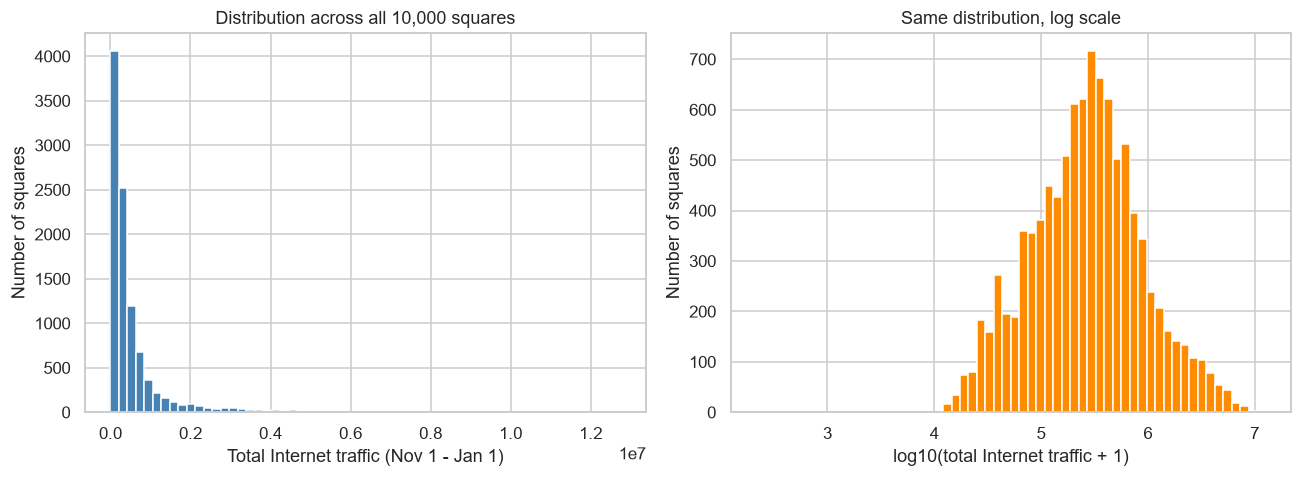

count    1.000000e+04
mean     5.552894e+05
std      8.925957e+05
min      2.136265e+02
25%      1.181020e+05
50%      2.778711e+05
75%      5.778956e+05
max      1.274006e+07
Name: total_internet_traffic, dtype: float64

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(ranking_df["total_internet_traffic"], bins=60, color="steelblue")
axes[0].set_xlabel("Total Internet traffic (Nov 1 - Jan 1)")
axes[0].set_ylabel("Number of squares")
axes[0].set_title("Distribution across all 10,000 squares")

axes[1].hist(np.log10(ranking_df["total_internet_traffic"] + 1), bins=60, color="darkorange")
axes[1].set_xlabel("log10(total Internet traffic + 1)")
axes[1].set_ylabel("Number of squares")
axes[1].set_title("Same distribution, log scale")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_traffic_distribution.png", bbox_inches="tight")
plt.show()

ranking_df["total_internet_traffic"].describe()

**Discussion.** Total traffic per square is strongly right-skewed: most squares are near the low end and a few carry much more (the busiest square has about 1.27e7 in total, see the ranking above). On a log scale the distribution looks roughly bell-shaped, centered around 10^5.5. The rest of the project uses only the three busiest squares.

### Spatial layout of the traffic

The 10,000 squares form a 100×100 grid. Assuming the ids run along rows of 100 squares, square `id` is at row `(id - 1) // 100` and column `(id - 1) % 100`. The map shows the total traffic per square with the top-3 squares and squares 4159 and 4556 marked.

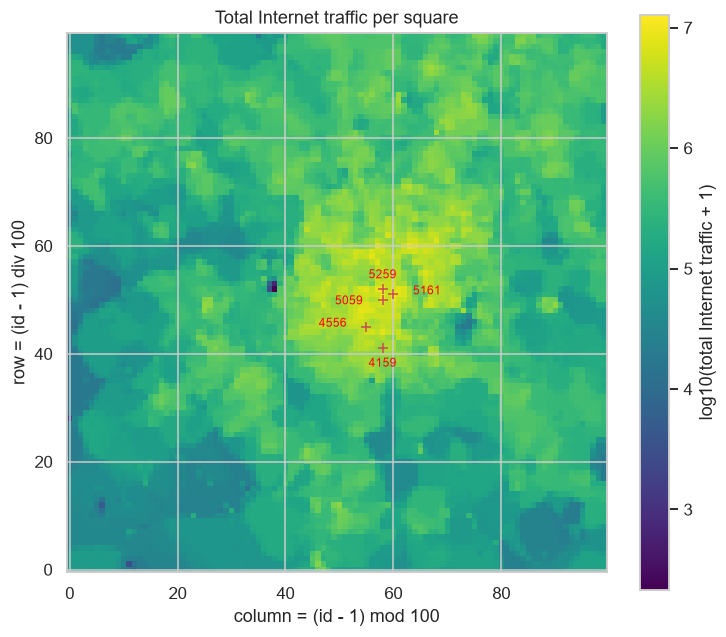

             square_5161  square_5059  square_5259  square_4159  square_4556
square_5161         1.00         0.88         0.47         0.49         0.39
square_5059         0.88         1.00         0.76         0.77         0.40
square_5259         0.47         0.76         1.00         0.90         0.30
square_4159         0.49         0.77         0.90         1.00         0.39
square_4556         0.39         0.40         0.30         0.39         1.00 

square_5161 correlation with the other two, Nov 1 - Dec 15, weekdays: square_5059: 0.93, square_5259: 0.84
square_5161 correlation with the other two, Nov 1 - Dec 15, weekends: square_5059: 0.95, square_5259: -0.05


In [11]:
grid = np.full((100, 100), np.nan)
ids = ranking_df["square_id"].to_numpy() - 1
grid[ids // 100, ids % 100] = ranking_df["total_internet_traffic"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(np.log10(grid + 1), origin="lower", cmap="viridis")
fig.colorbar(im, ax=ax, label="log10(total Internet traffic + 1)")
offsets = {5059: (-22, -3), 5161: (22, 0), 5259: (0, 7), 4159: (0, -12), 4556: (-22, 0)}
for sid in top3_ids + landmark_ids:
    x, y = (sid - 1) % 100, (sid - 1) // 100
    ax.plot(x, y, "r+")
    ax.annotate(str(sid), (x, y), xytext=offsets[sid], textcoords="offset points", color="red", fontsize=8, ha="center")
ax.set_xlabel("column = (id - 1) mod 100")
ax.set_ylabel("row = (id - 1) div 100")
ax.set_title("Total Internet traffic per square")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_spatial_traffic_map.png", bbox_inches="tight")
plt.show()

print(wide[top3_cols + landmark_cols].corr().round(2), "\n")
early = wide.loc[:"2013-12-15", top3_cols]
for name, mask in [("weekdays", early.index.dayofweek < 5), ("weekends", early.index.dayofweek >= 5)]:
    c = early[mask].corr().loc[top3_cols[0], top3_cols[1:]].round(2)
    print(f"{top3_cols[0]} correlation with the other two, Nov 1 - Dec 15, {name}: " + ", ".join(f"{k}: {v}" for k, v in c.items()))

**Discussion.** Traffic is concentrated in space: the 100 busiest squares (1% of the grid) carry 11% of the total and the 1,000 busiest (10%) carry 48%, and the high-traffic squares form a compact area in the middle of the map. The three busiest squares are close together, at (row, column) (50, 58) for 5059, (51, 60) for 5161 and (52, 58) for 5259. Square 4159 is at (41, 58), 11 rows below 5259, and 4556 is at (45, 55).

Being close does not mean behaving alike. Square 5161 is the same distance from 5059 and from 5259 (1 row and 2 columns), yet its series correlates at 0.88 with 5059 and only 0.47 with 5259, while 5259 and 4159, 11 rows apart, correlate at 0.90. This follows the weekend behaviour seen in the time series plots: between Nov 1 and Dec 15 the correlation of 5161 with 5259 is 0.84 on weekdays and -0.05 on weekends, and with 5059 it is 0.93 and 0.95. I did not check what is located at these squares, so I can only say that 5259 and 4159 look like areas used mainly on working days and 5161 does not.

### Time series for the top-3 squares and squares 4159 and 4556 (first two weeks)

Nov 1–14, 2013 at 10-minute resolution: first the three busiest squares, then 4159 and 4556.

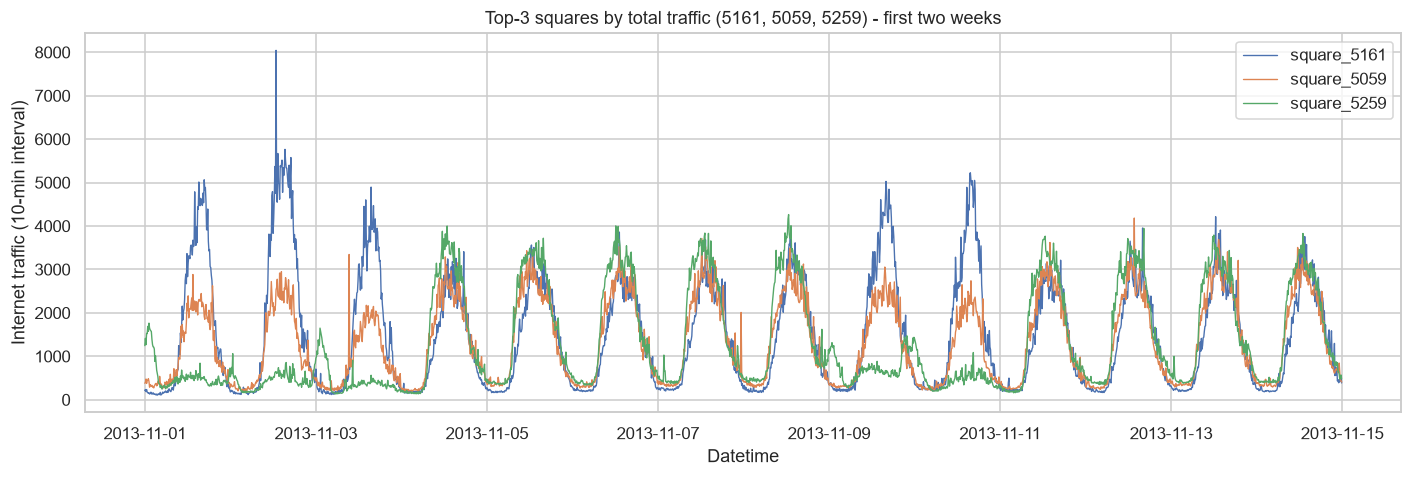

In [12]:
two_weeks = wide.loc["2013-11-01":"2013-11-14"]

fig, ax = plt.subplots(figsize=(13, 4.5))
for col in top3_cols:
    ax.plot(two_weeks.index, two_weeks[col], label=col, linewidth=0.9)
ax.set_xlabel("Datetime")
ax.set_ylabel("Internet traffic (10-min interval)")
ax.set_title(f"Top-3 squares by total traffic ({', '.join(str(s) for s in top3_ids)}) - first two weeks")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_timeseries_top3_first2weeks.png", bbox_inches="tight")
plt.show()

**Discussion.** All three squares have a daily cycle with a low overnight trough (a few hundred) and a daytime peak. On weekdays (Nov 4–8 and 11–14) they look alike, with peaks of roughly 3,000–4,000. On weekends (Nov 2–3 and 9–10) they behave very differently: square 5161 has its highest peaks of the two weeks (about 5,000, and 8,044 on Saturday Nov 2), 5059 peaks around 2,000–2,800, and 5259 stays close to 500. Nov 1 (a Friday and a public holiday in Italy) also looks like a weekend day. So the squares differ in their weekly pattern and not only in size, and the models in notebook 2 need a weekly component (day-of-week features for the LSTM and TCN, weekly Fourier terms for SARIMA).

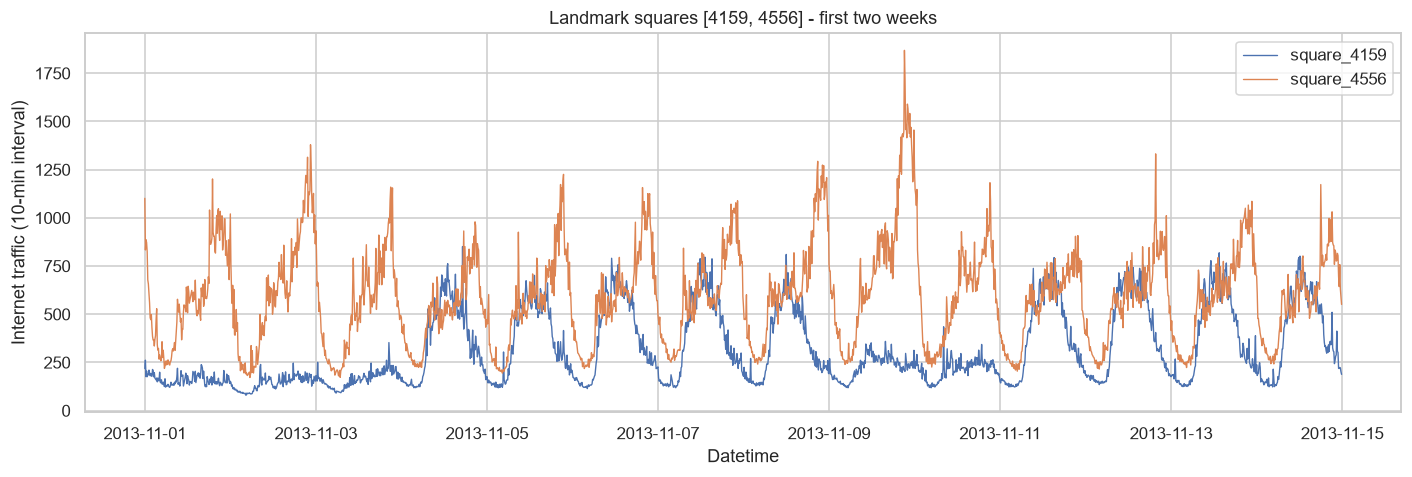

In [13]:
fig, ax = plt.subplots(figsize=(13, 4.5))
for col in landmark_cols:
    ax.plot(two_weeks.index, two_weeks[col], label=col, linewidth=0.9)
ax.set_xlabel("Datetime")
ax.set_ylabel("Internet traffic (10-min interval)")
ax.set_title(f"Landmark squares {landmark_ids} - first two weeks")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_timeseries_landmarks_first2weeks.png", bbox_inches="tight")
plt.show()

In [14]:
cols = top3_cols + landmark_cols
summary = two_weeks[cols].agg(["mean", "max", "std"]).T
summary["cv"] = summary["std"] / summary["mean"]
summary["peak_to_mean"] = summary["max"] / summary["mean"]
weekend = two_weeks.index.dayofweek >= 5
summary["weekday_mean"] = two_weeks.loc[~weekend, cols].mean()
summary["weekend_mean"] = two_weeks.loc[weekend, cols].mean()
summary = summary.round(2)
summary["peak_time"] = two_weeks[cols].idxmax()
summary

,mean,max,std,cv,peak_to_mean,weekday_mean,weekend_mean,peak_time
square_5161,1483.790039,8044.069824,1312.599976,0.88,5.42,1381.479980,1739.569946,2013-11-02 12:50:00
square_5059,1330.550049,4182.759766,952.469971,0.72,3.14,1423.650024,1097.810059,2013-11-12 13:40:00
square_5259,1292.260010,4262.899902,1137.250000,0.88,3.30,1598.500000,526.659973,2013-11-08 12:40:00
square_4159,311.369995,851.049988,189.250000,0.61,2.73,361.119995,186.990005,2013-11-04 17:10:00
square_4556,591.640015,1868.739990,254.649994,0.43,3.16,577.330017,627.429993,2013-11-09 21:10:00


**Discussion.** Squares 4159 and 4556 carry much less traffic than the top three (means of 311 and 592 over these two weeks, against 1,292–1,484; see the table above). 4159 is a weekday square: it sits at about 150–250 on weekends and on Nov 1 and reaches about 700–800 on weekdays. 4556 has a daily cycle every day, is noisier, and its largest peak (1,869) is on Saturday Nov 9 at 21:10; I did not look into what caused it.

The table also shows how volatility differs between squares. Square 5161 has a coefficient of variation of 0.88 and a peak-to-mean ratio of 5.4, against 0.43 and 3.2 for 4556 (5059: 0.72 and 3.1, 5259: 0.88 and 3.3, 4159: 0.61 and 2.7). Squares 5161 and, slightly, 4556 are busier on weekends; the other three are busier on weekdays (5059: 1,424 vs 1,098, 5259: 1,599 vs 527, 4159: 361 vs 187). In notebook 2, 5161 is the square where the LSTM does worst compared with SARIMA.

### STL decomposition of the top-1 square

STL with a period of 144 (one day) on the full Nov 1 – Jan 1 series of square 5161.

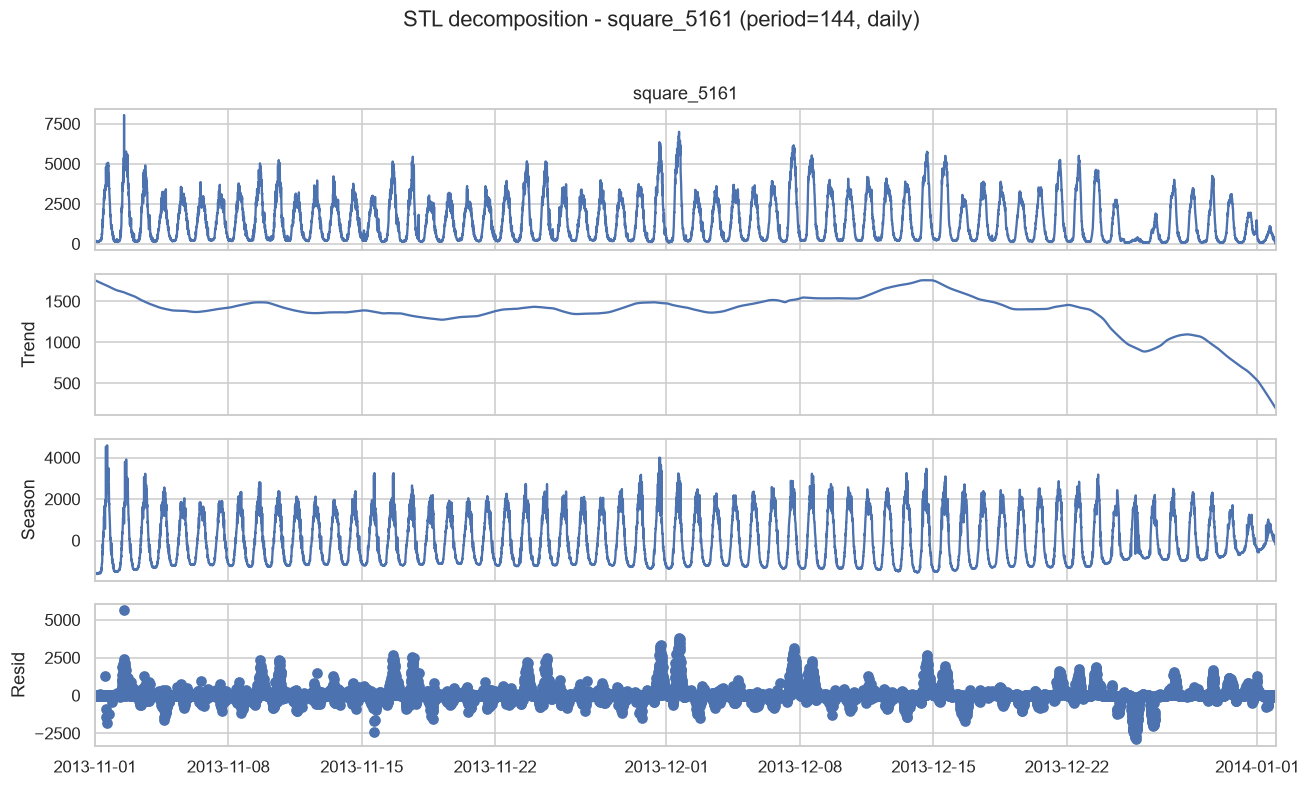

Seasonal strength: 0.858, Trend strength: 0.238


In [15]:
top1_col = top3_cols[0]
top1_series = wide[top1_col]

stl = STL(top1_series, period=144, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(12, 7)
fig.suptitle(f"STL decomposition - {top1_col} (period=144, daily)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_stl_top1.png", bbox_inches="tight")
plt.show()

seasonal_strength = 1 - stl_result.resid.var() / (stl_result.seasonal + stl_result.resid).var()
trend_strength = 1 - stl_result.resid.var() / (stl_result.trend + stl_result.resid).var()
print(f"Seasonal strength: {seasonal_strength:.3f}, Trend strength: {trend_strength:.3f}")

pd.DataFrame([{"square": top1_col, "seasonal_strength": seasonal_strength, "trend_strength": trend_strength}]).to_csv(
    RESULTS_DIR / "stl_strength_top1.csv", index=False
)

**Discussion.** The seasonal component is large and regular (seasonal strength 0.858, trend strength 0.238). The trend stays between about 1,300 and 1,750 until roughly Dec 22 and then drops sharply towards the end of the year, and the residual has its largest negative values around Dec 25–26, when the daily peaks are far below the usual pattern. The drop starts close to the end of the Dec 16–22 test week. Outside the holiday period most of the variance is explained by the daily cycle, so the remaining error comes from deviations from that pattern.

### Stationarity and autocorrelation structure of the top-1 square (ACF, PACF, ADF)

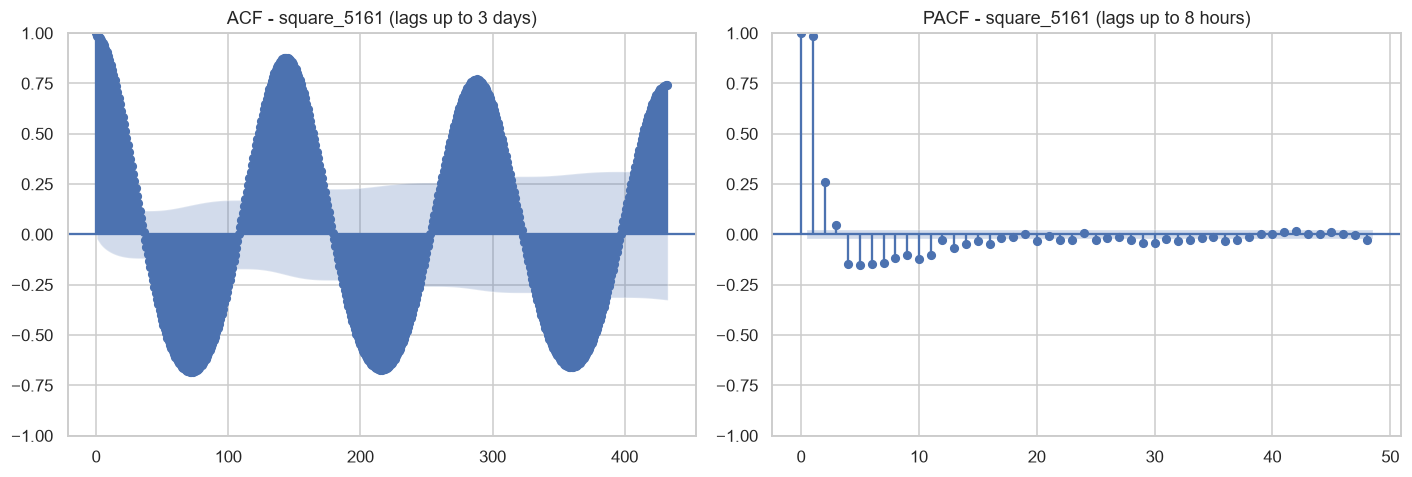

C:\Users\EVOTECH SOL\AppData\Local\Temp\ipykernel_11180\2308010925.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_pvalue, adf_lags, adf_nobs, adf_crit, _ = adfuller(top1_series, autolag="AIC")


,square,adf_statistic,p_value,n_lags_used,n_obs,crit_1%,crit_5%,crit_10%
0,square_5161,-19.027761,0.0,36,8891,-3.431086,-2.861865,-2.566943


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(top1_series, lags=432, ax=axes[0])
axes[0].set_title(f"ACF - {top1_col} (lags up to 3 days)")
plot_pacf(top1_series, lags=48, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF - {top1_col} (lags up to 8 hours)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_acf_pacf_top1.png", bbox_inches="tight")
plt.show()

adf_stat, adf_pvalue, adf_lags, adf_nobs, adf_crit, _ = adfuller(top1_series, autolag="AIC")
adf_result = pd.DataFrame([{
    "square": top1_col, "adf_statistic": adf_stat, "p_value": adf_pvalue,
    "n_lags_used": adf_lags, "n_obs": adf_nobs, **{f"crit_{k}": v for k, v in adf_crit.items()},
}])
adf_result.to_csv(RESULTS_DIR / "adf_test_top1.csv", index=False)
adf_result

In [17]:
from statsmodels.tsa.stattools import acf

acf_values = acf(top1_series, nlags=1008)
print(f"ACF of {top1_col}: lag 144 (1 day) = {acf_values[144]:.3f}, lag 1008 (1 week) = {acf_values[1008]:.3f}")

ACF of square_5161: lag 144 (1 day) = 0.878, lag 1008 (1 week) = 0.838


**Discussion.** The ACF has strong peaks at lag 144 and its multiples (0.878 at 144, 0.770 at 288, 0.741 at 432), which confirms the daily cycle. The ACF at lag 1008 (one week) is 0.838, almost as high as at lag 144, so the weekly pattern repeats nearly as strongly as the daily one; the STL decomposition above only removes the daily period. The PACF is large at lags 1 and 2 (0.987 and 0.259) and small afterwards (about -0.15 at lags 4–6), which points to a low AR order. The ADF test rejects the unit root (statistic -19.0, p < 0.001), so the series is stationary in that sense and does not need differencing to remove a trend. In notebook 2 the order with d=1, `(2,1,1)`, has the lowest AIC on all three squares.

## Files saved for notebook 2

- `data/processed/timeseries_selected_squares.parquet`: 10-minute series (missing intervals filled with 0) for squares 5161, 5059, 5259 (top-3) and 4159, 4556
- `results/square_ranking.csv`: all squares ranked by total traffic
- `results/memory_usage.csv`, `results/stl_strength_top1.csv`, `results/adf_test_top1.csv`
- `figures/eda_*.png`